# Comparison and Testing of BaselineGAT with Custom MPNN
## Loading and split dataset for BaselineGNNs

In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np

[19:55:18] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[19:55:18] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[19:55:18] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[19:55:18] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


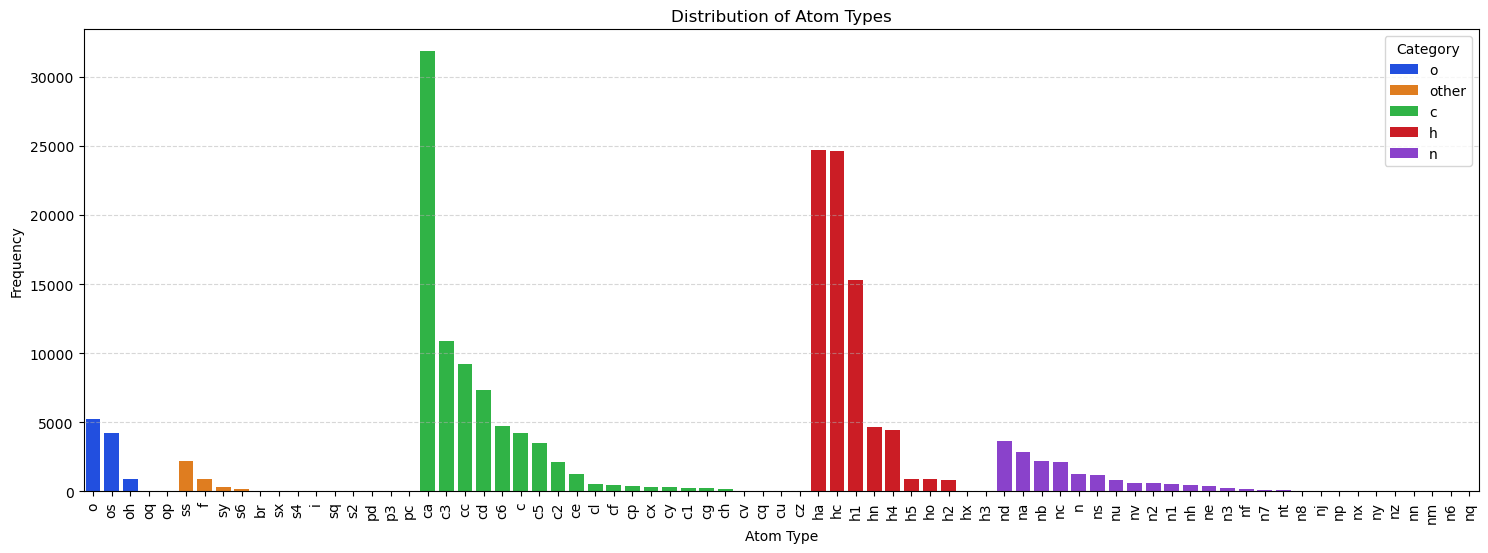

,Atom Type,Count,Category
0,o,5248,o
1,os,4222,o
2,oh,879,o
3,oq,12,o
4,op,5,o
...,...,...,...
70,nz,4,n
71,nn,4,n
72,nm,3,n
73,n6,3,n


In [2]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

## Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

BaselineGCN - Number of parameters: 379467


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7678 | Val Loss: 0.7603
Epoch - 20: Train Loss: 0.6767 | Val Loss: 0.6976
Epoch - 30: Train Loss: 0.6350 | Val Loss: 0.6528


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.6097 | Val Loss: 0.6313
Epoch - 20: Train Loss: 0.5947 | Val Loss: 0.6215
Epoch - 30: Train Loss: 0.5823 | Val Loss: 0.6214


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5791 | Val Loss: 0.5753
Epoch - 20: Train Loss: 0.5737 | Val Loss: 0.5727
Epoch - 30: Train Loss: 0.5641 | Val Loss: 0.5741


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5548 | Val Loss: 0.5729
Epoch - 20: Train Loss: 0.5485 | Val Loss: 0.5786
Epoch - 30: Train Loss: 0.5432 | Val Loss: 0.5795


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5440 | Val Loss: 0.5593
Epoch - 20: Train Loss: 0.5388 | Val Loss: 0.5553
Epoch - 30: Train Loss: 0.5330 | Val Loss: 0.5637


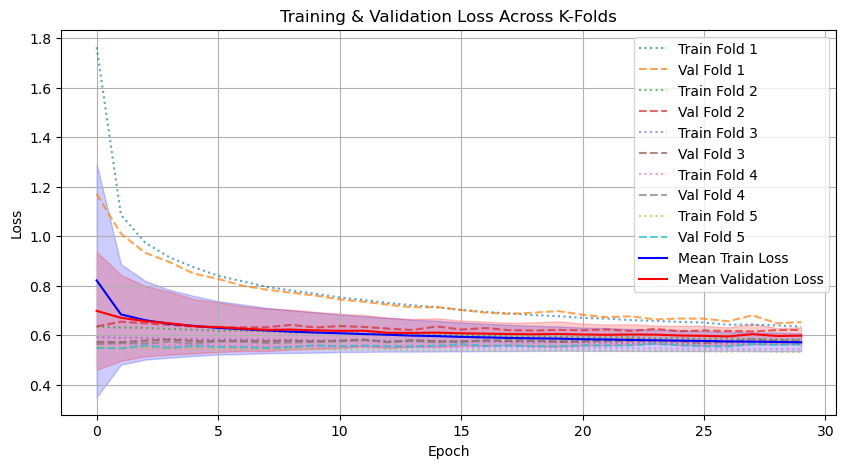

Evaluation Metrics: {'Accuracy': 0.769803438487494, 'F1-score': 0.7561375982720985}


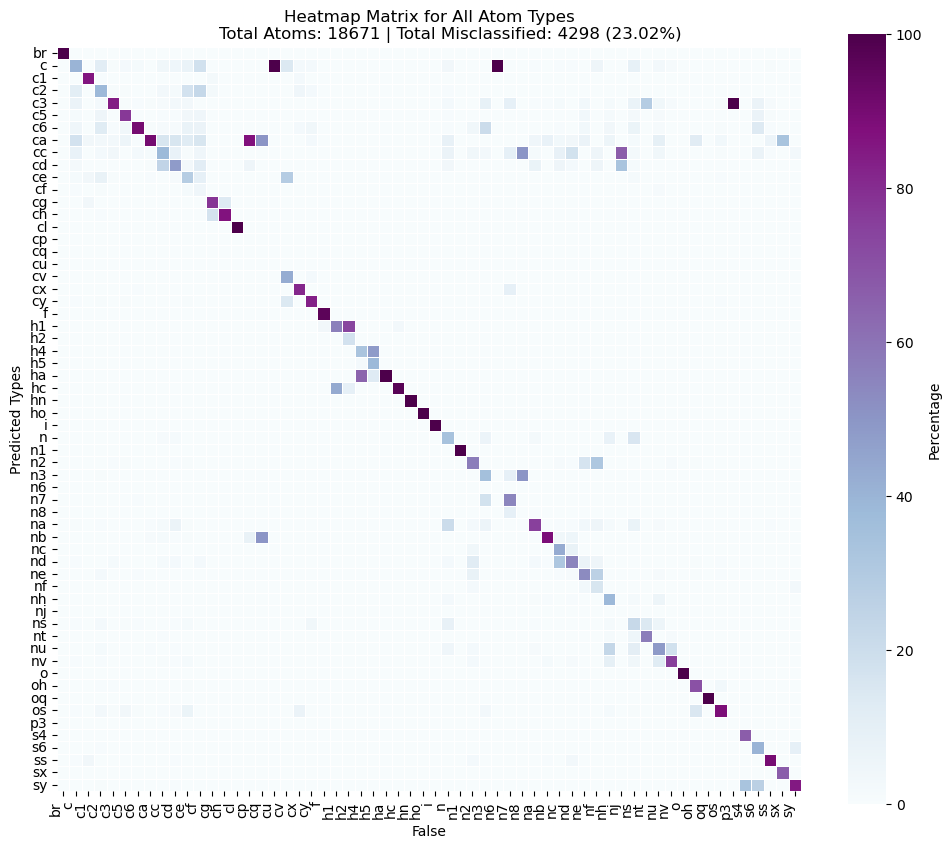

In [3]:
# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

plot_full_heatmap(y_true=y_true_labels, y_pred=y_pred_labels)


# Testing BaselineGAT - 2 layer Graph Convulutions with attention mechanism nn on atom features only with elu activation functions

BaselineGAT - Number of parameters: 1406027


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5878 | Val Loss: 0.5683
Epoch - 20: Train Loss: 0.5175 | Val Loss: 0.5263
Epoch - 30: Train Loss: 0.4928 | Val Loss: 0.4868


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4730 | Val Loss: 0.4916
Epoch - 20: Train Loss: 0.4665 | Val Loss: 0.4948
Epoch - 30: Train Loss: 0.4589 | Val Loss: 0.4947


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4636 | Val Loss: 0.4556
Epoch - 20: Train Loss: 0.4568 | Val Loss: 0.4560
Epoch - 30: Train Loss: 0.4562 | Val Loss: 0.4528


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4486 | Val Loss: 0.4742
Epoch - 20: Train Loss: 0.4485 | Val Loss: 0.4809
Epoch - 30: Train Loss: 0.4386 | Val Loss: 0.4800


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4403 | Val Loss: 0.4534
Epoch - 20: Train Loss: 0.4375 | Val Loss: 0.4515
Epoch - 30: Train Loss: 0.4350 | Val Loss: 0.4520


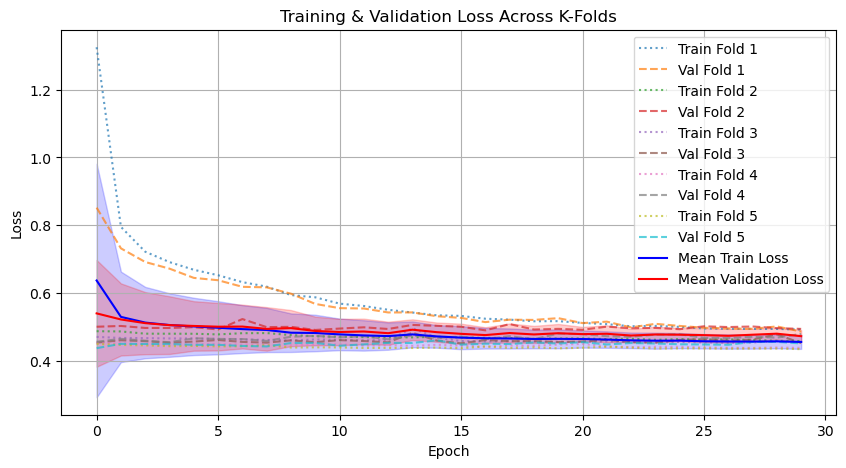

Evaluation Metrics: {'Accuracy': 0.8173638262546195, 'F1-score': 0.8061093042082008}


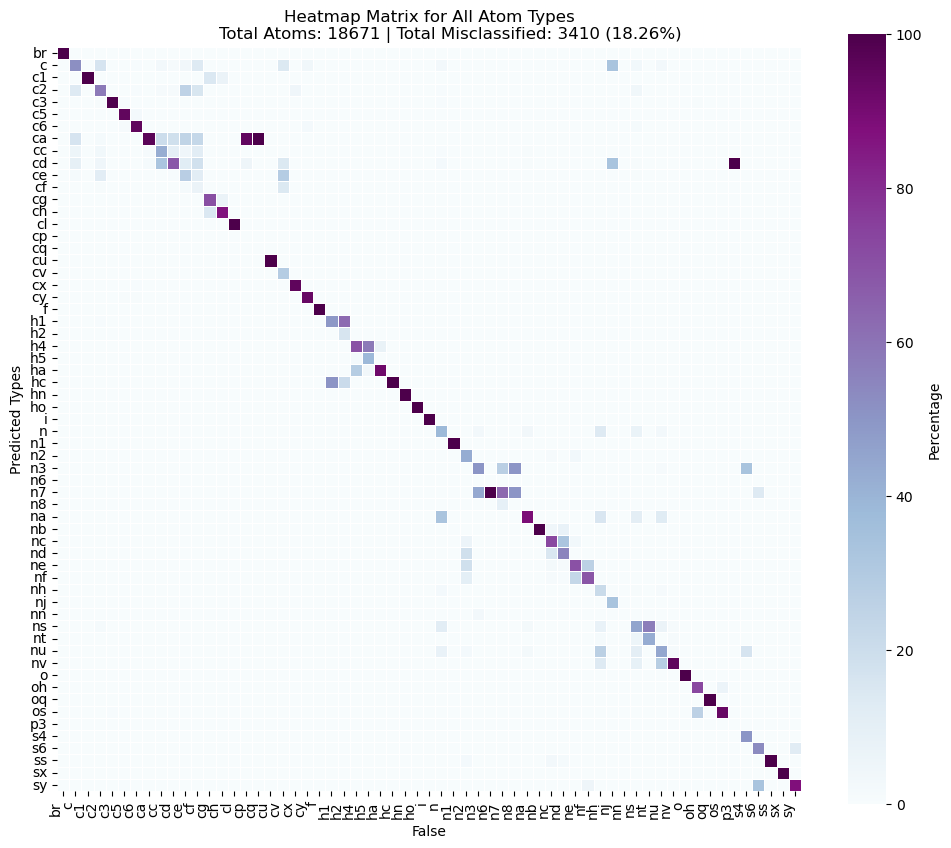

In [4]:
# Initialize baselineGNN for classification
model_GAT = BaselineGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512, heads=4)
trainer_GAT = GNNTrainer(model_GAT, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GAT.train()
metrics_GAT = trainer_GAT.evaluate_model(test_dataset)

y_true_GAT, y_pred_GAT = trainer_GAT.predict(test_dataset)

plot_full_heatmap(y_true=y_true_GAT, y_pred=y_pred_GAT)


# Testing MPNN_4Layer - 4 layer standard MPNN nn on atom features only with relu activation functions

MPNN_4L - Number of parameters: 1626315


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.4634 | Val Loss: 0.4292
Epoch - 20: Train Loss: 0.4168 | Val Loss: 0.3995
Epoch - 30: Train Loss: 0.3971 | Val Loss: 0.3874


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.3831 | Val Loss: 0.3914
Epoch - 20: Train Loss: 0.3698 | Val Loss: 0.3882
Epoch - 30: Train Loss: 0.3587 | Val Loss: 0.3954


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.3587 | Val Loss: 0.3456
Epoch - 20: Train Loss: 0.3504 | Val Loss: 0.3505
Epoch - 30: Train Loss: 0.3403 | Val Loss: 0.3548


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.3353 | Val Loss: 0.3483
Epoch - 20: Train Loss: 0.3330 | Val Loss: 0.3604
Epoch - 30: Train Loss: 0.3205 | Val Loss: 0.3784


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.3237 | Val Loss: 0.3210
Epoch - 20: Train Loss: 0.3183 | Val Loss: 0.3313
Epoch - 30: Train Loss: 0.3112 | Val Loss: 0.3430


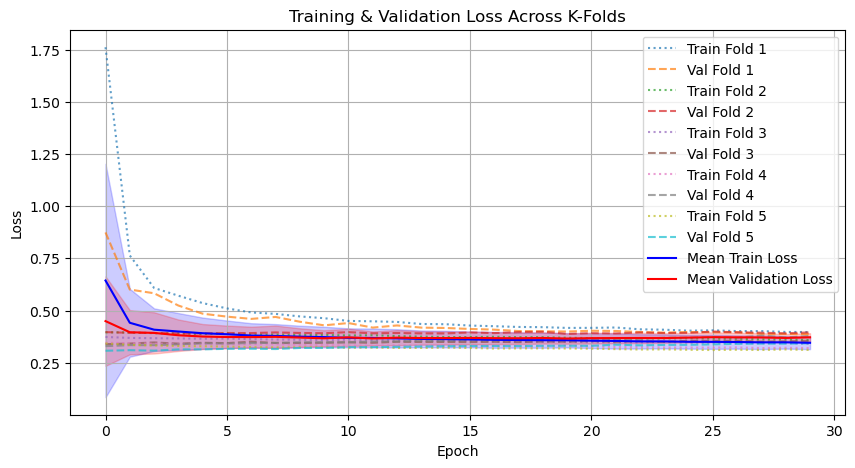

Evaluation Metrics: {'Accuracy': 0.8604788174173853, 'F1-score': 0.8546609427556645}


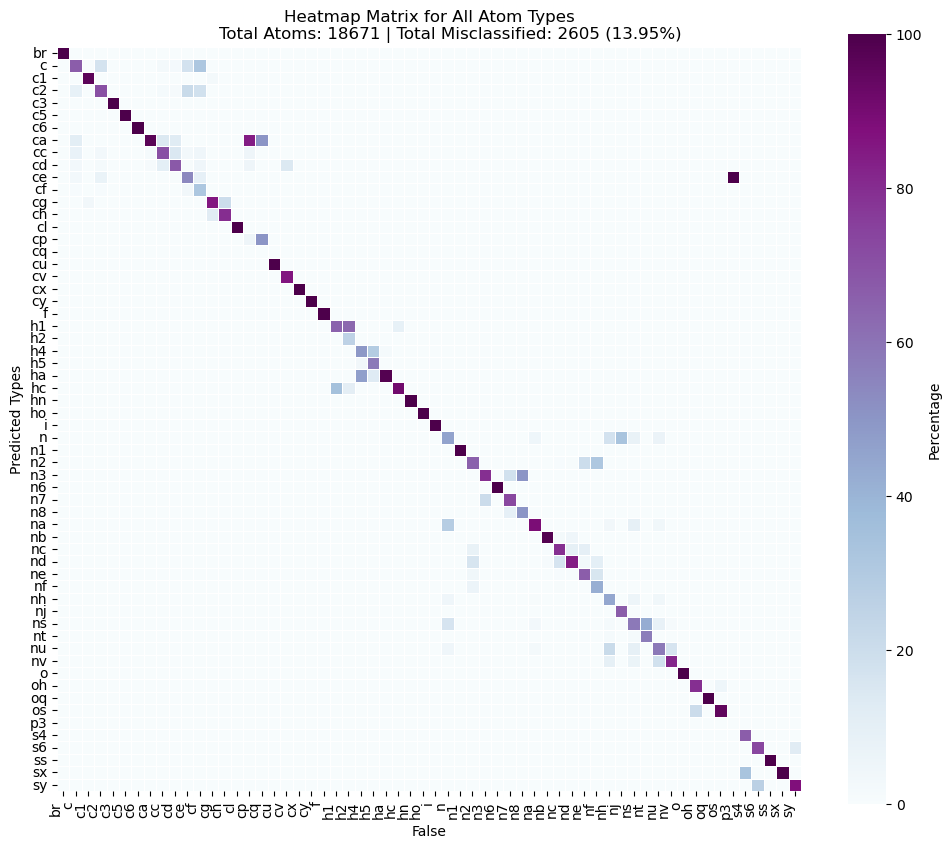

In [5]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import MPNN_4L

# Initialize baselineGNN for classification
model_MPNN_4L = MPNN_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer_MPNN_4L = GNNTrainer(model_MPNN_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_MPNN_4L.train()
metrics_MPNN_4L = trainer_MPNN_4L.evaluate_model(test_dataset)

y_true_MPNN_4L, y_pred_MPNN_4L = trainer_MPNN_4L.predict(test_dataset)

plot_full_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

# Loading MPNNdataset - Directed Bond Graphs for custom D-MPNN

In [10]:
import importlib
importlib.reload(atoMLtype.GNN.GNNdataset)
from atoMLtype.GNN.GNNdataset import MPNNdataset

In [11]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
mpnn_test_dataset = MPNNdataset(sdf_path, json_labels, collapse=True)

[20:50:00] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[20:50:00] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[20:50:00] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[20:50:01] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

FULL DATASET:


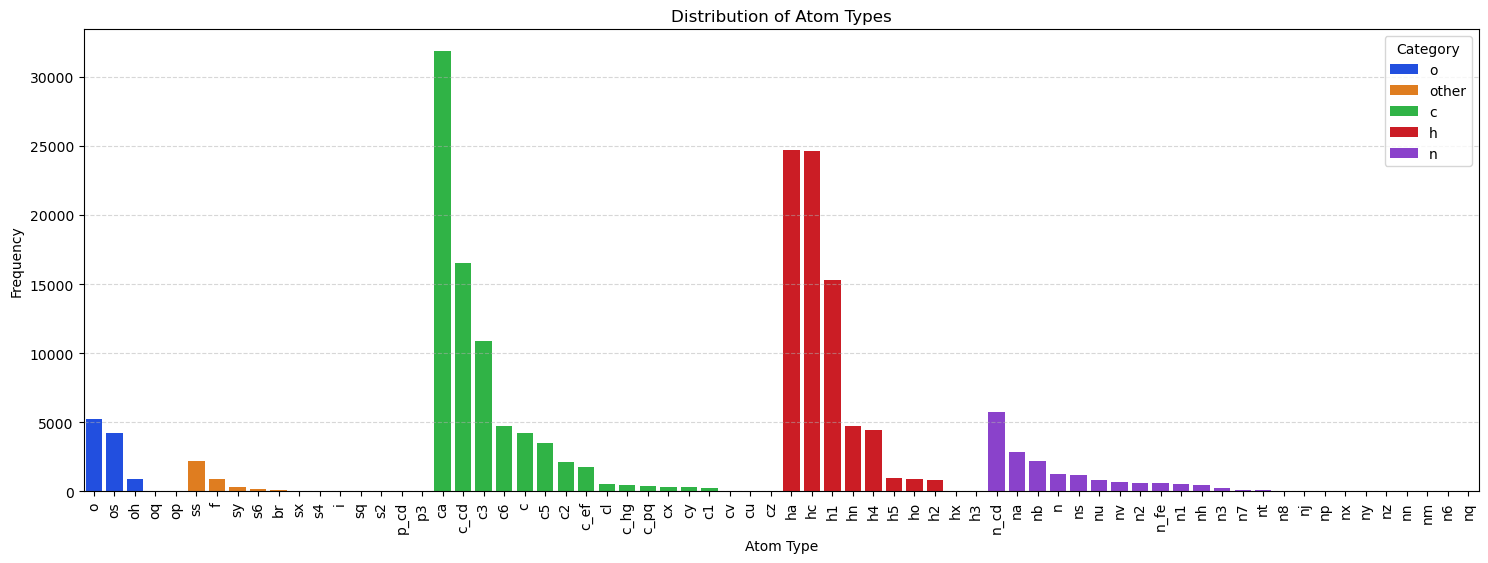

num_atom_features = 154
num_bond_features = 14
num_y_ATs = 68
Total dataset size: 6390
Train split size: 5751
Test split size: 639
First train sample: Data(x=[33, 154], edge_index=[2, 72], edge_attr=[72, 14], y=[33], y_values=[33], mol_name='ZINC61130726')
First test sample: Data(x=[37, 154], edge_index=[2, 80], edge_attr=[80, 14], y=[37], y_values=[37], mol_name='ZINC19374881')


In [14]:
# Initialize dataset
num_atom_feat = mpnn_test_dataset[0].x.shape[1]
num_bond_feat = mpnn_test_dataset[0].edge_attr.shape[1]
num_y_ATs = len(set(mpnn_test_dataset.all_labels))

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(mpnn_test_dataset))
test_size = len(mpnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(mpnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(mpnn_test_dataset.all_labels))

print(f"num_atom_features = {num_atom_feat}")
print(f"num_bond_features = {num_bond_feat}")
print(f"num_y_ATs = {num_y_ATs}")

print("Total dataset size:", len(mpnn_test_dataset))
print("Train split size:", len(train_dataset))
print("Test split size:", len(test_dataset))

# Check first few samples from each to ensure they aren't empty
print("First train sample:", train_dataset[0])
print("First test sample:", test_dataset[0])

Att_AtomBondMPNN - Number of parameters: 10985550


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.0229 | Val Loss: 0.0131
Epoch - 20: Train Loss: 0.0268 | Val Loss: 0.0538
Epoch - 30: Train Loss: 0.0111 | Val Loss: 0.0088


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.0384 | Val Loss: 0.0284
Epoch - 20: Train Loss: 0.0071 | Val Loss: 0.0297
Epoch - 30: Train Loss: 0.0303 | Val Loss: 0.0421


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.0059 | Val Loss: 0.0150
Epoch - 20: Train Loss: 0.0111 | Val Loss: 0.0175
Epoch - 30: Train Loss: 0.0109 | Val Loss: 0.0169


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.0091 | Val Loss: 0.0159
Epoch - 20: Train Loss: 0.0051 | Val Loss: 0.0099
Epoch - 30: Train Loss: 0.0048 | Val Loss: 0.0130


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.0056 | Val Loss: 0.0037
Epoch - 20: Train Loss: 0.0044 | Val Loss: 0.0064
Epoch - 30: Train Loss: 0.0049 | Val Loss: 0.0063


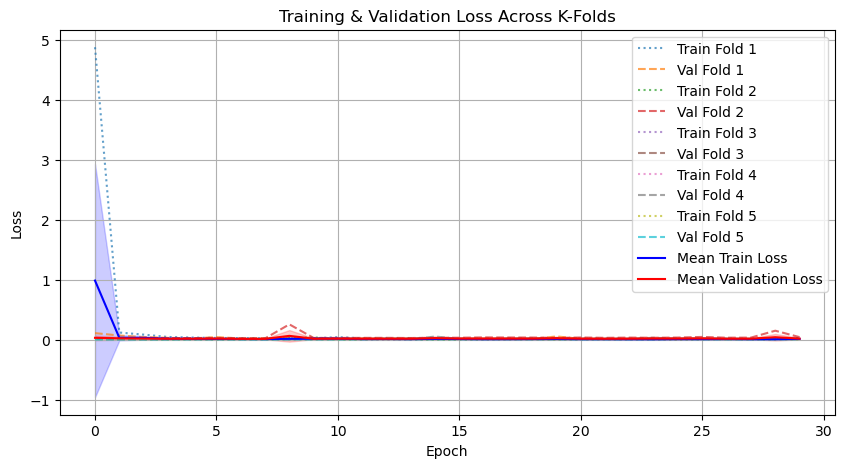

Evaluation Metrics: {'Accuracy': 0.9956861687786466, 'F1-score': 0.9956865082858489}


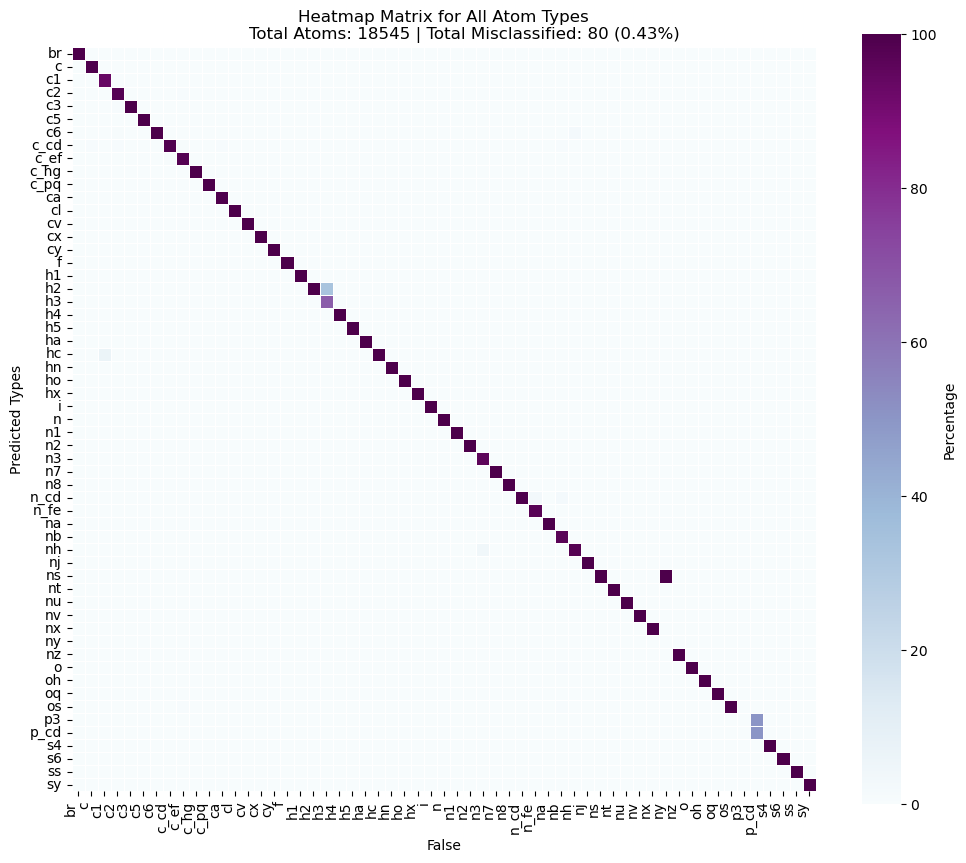

In [20]:
from atoMLtype.GNN.GNNmodel import Att_AtomBondMPNN

model_AtomMPNN = Att_AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_AtomMPNN.train()
metrics_AtomMPNN  = trainer_AtomMPNN .evaluate_model(test_dataset)

y_true_AtomMPNN, y_pred_AtomMPNN  = trainer_AtomMPNN .predict(test_dataset)

plot_full_heatmap(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN )

In [21]:
from atoMLtype.utils.metrics import plot_full_cross_intra_confusion_matices, plot_category_confusion_matrices

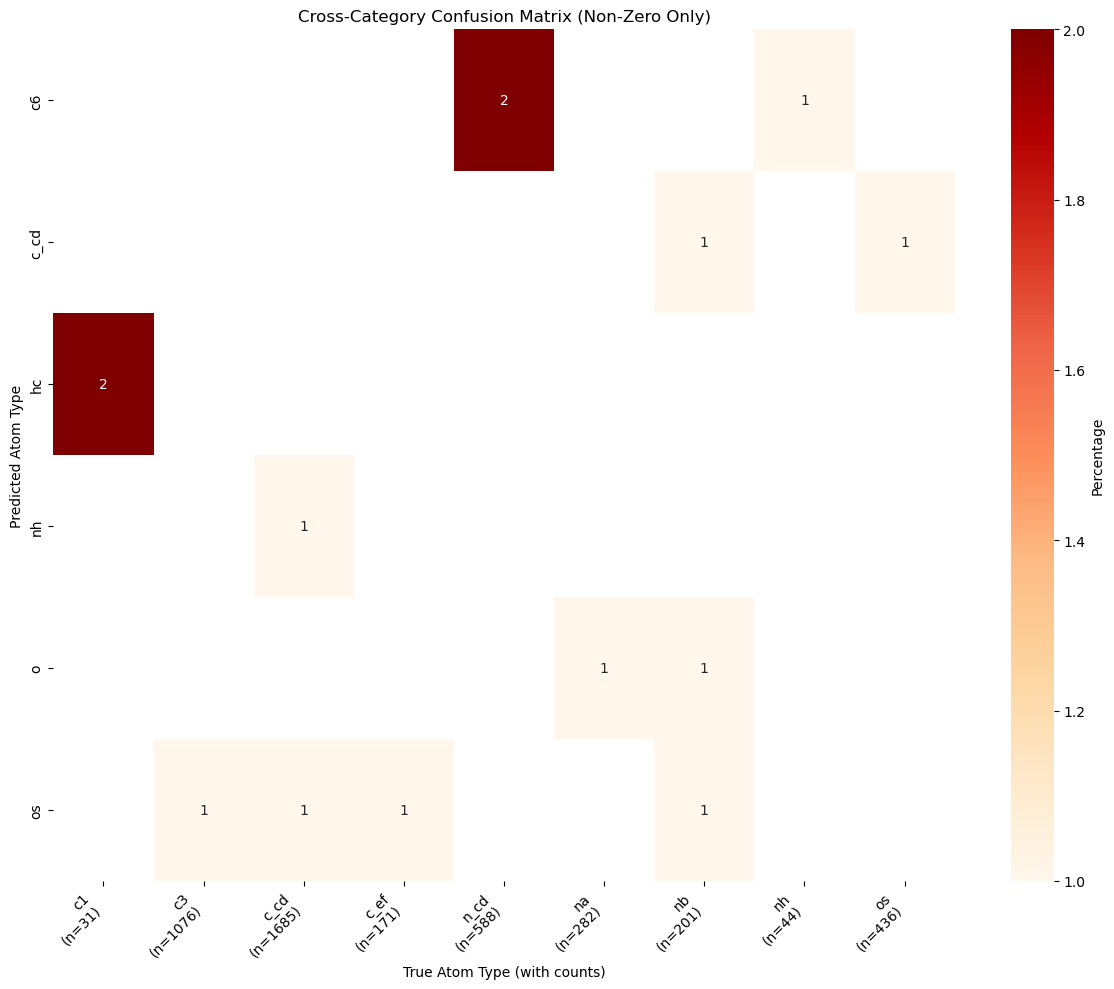

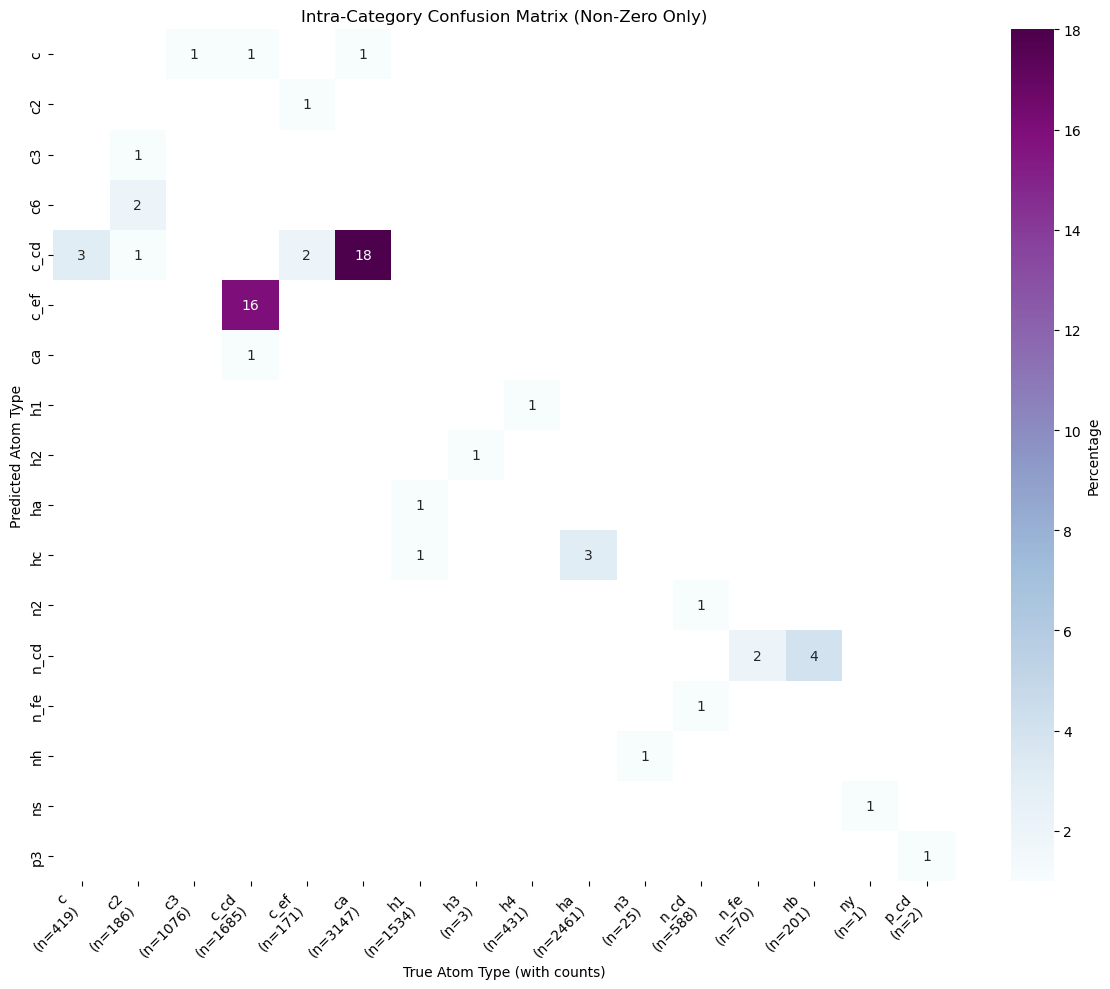

In [22]:
plot_full_cross_intra_confusion_matices(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN)

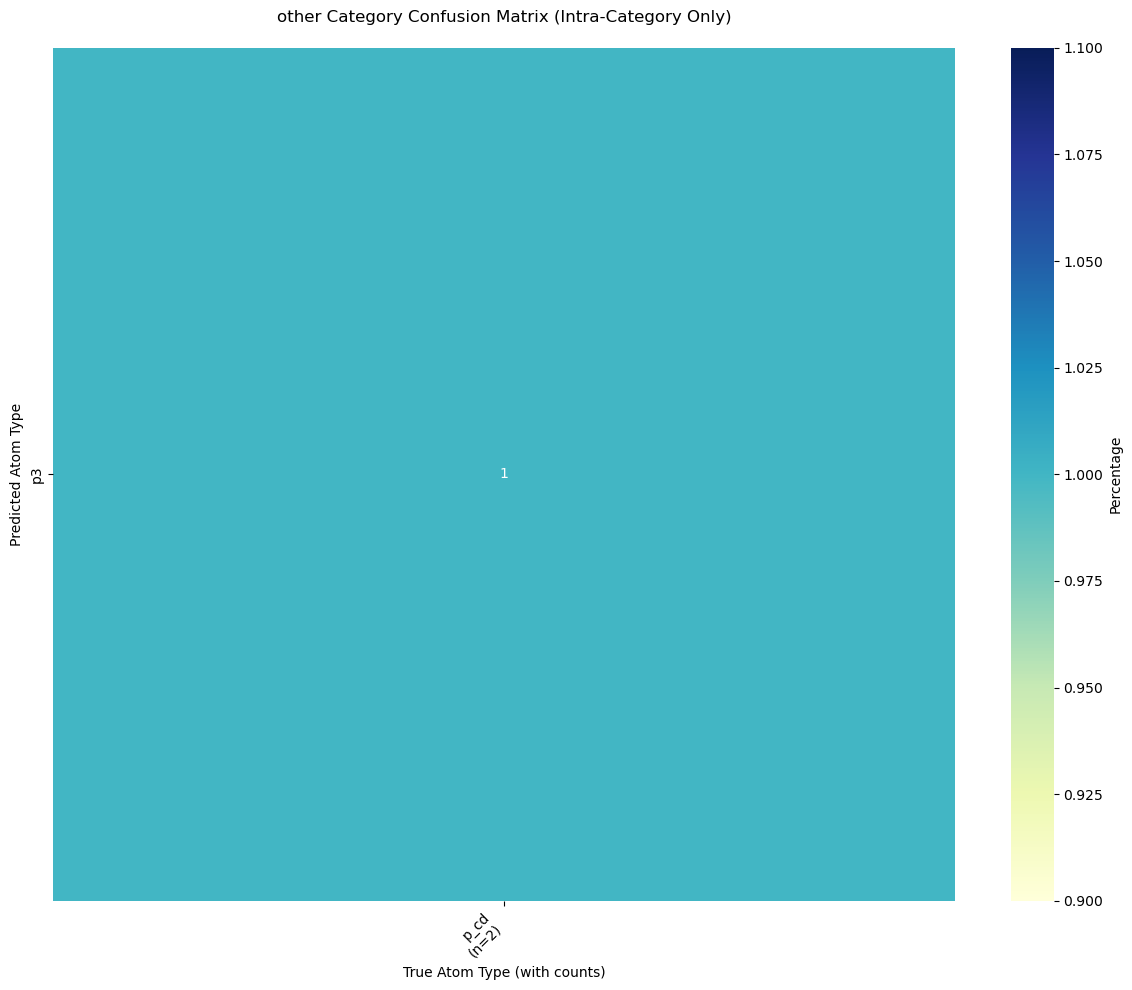

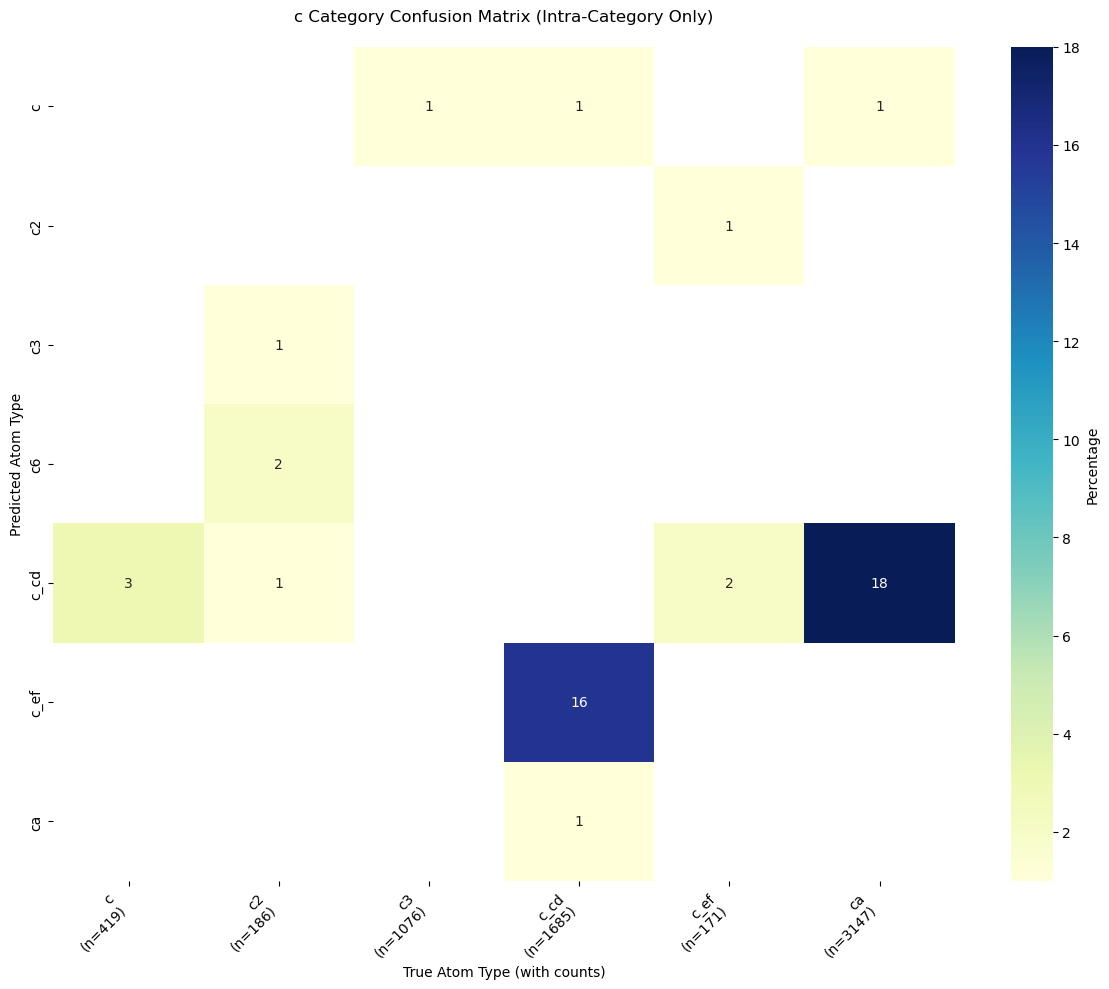

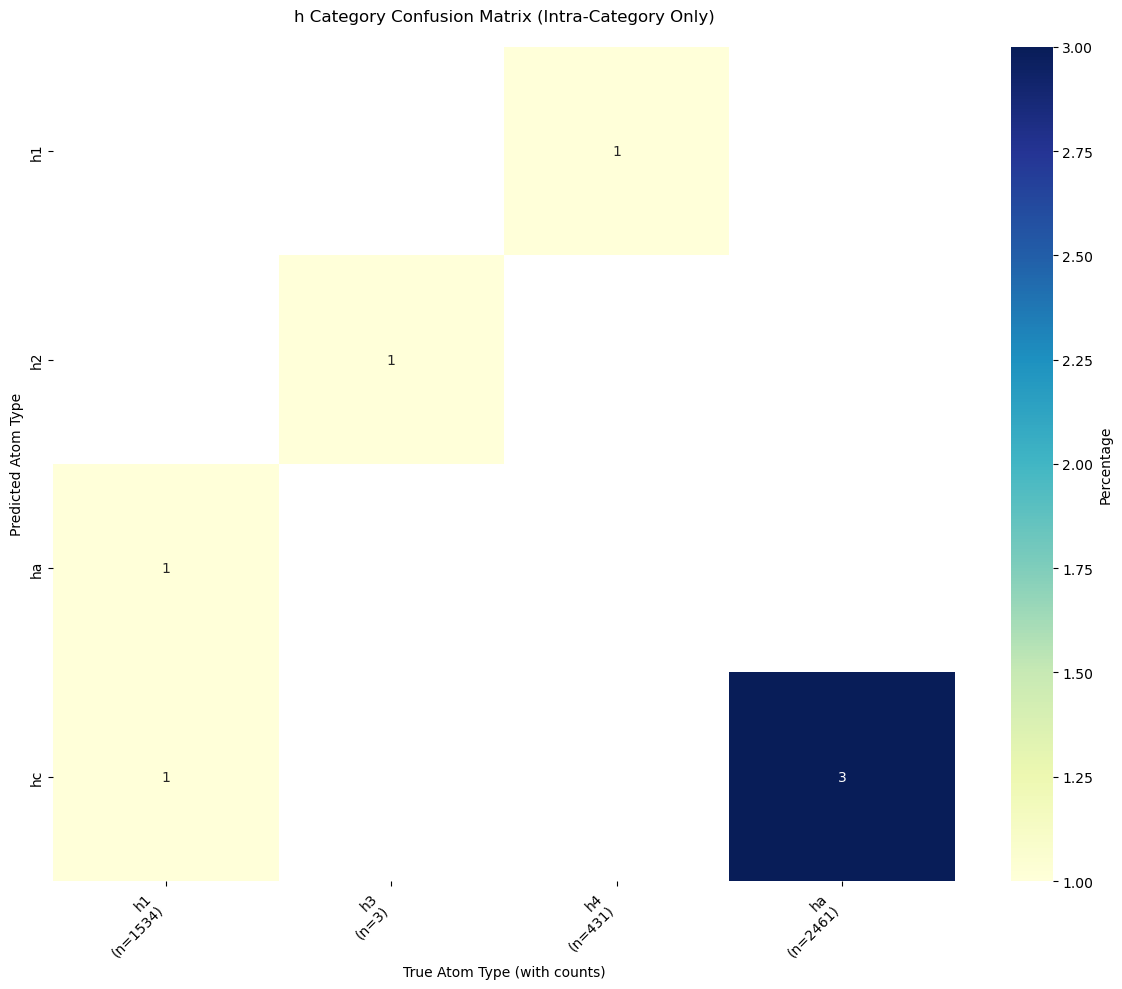

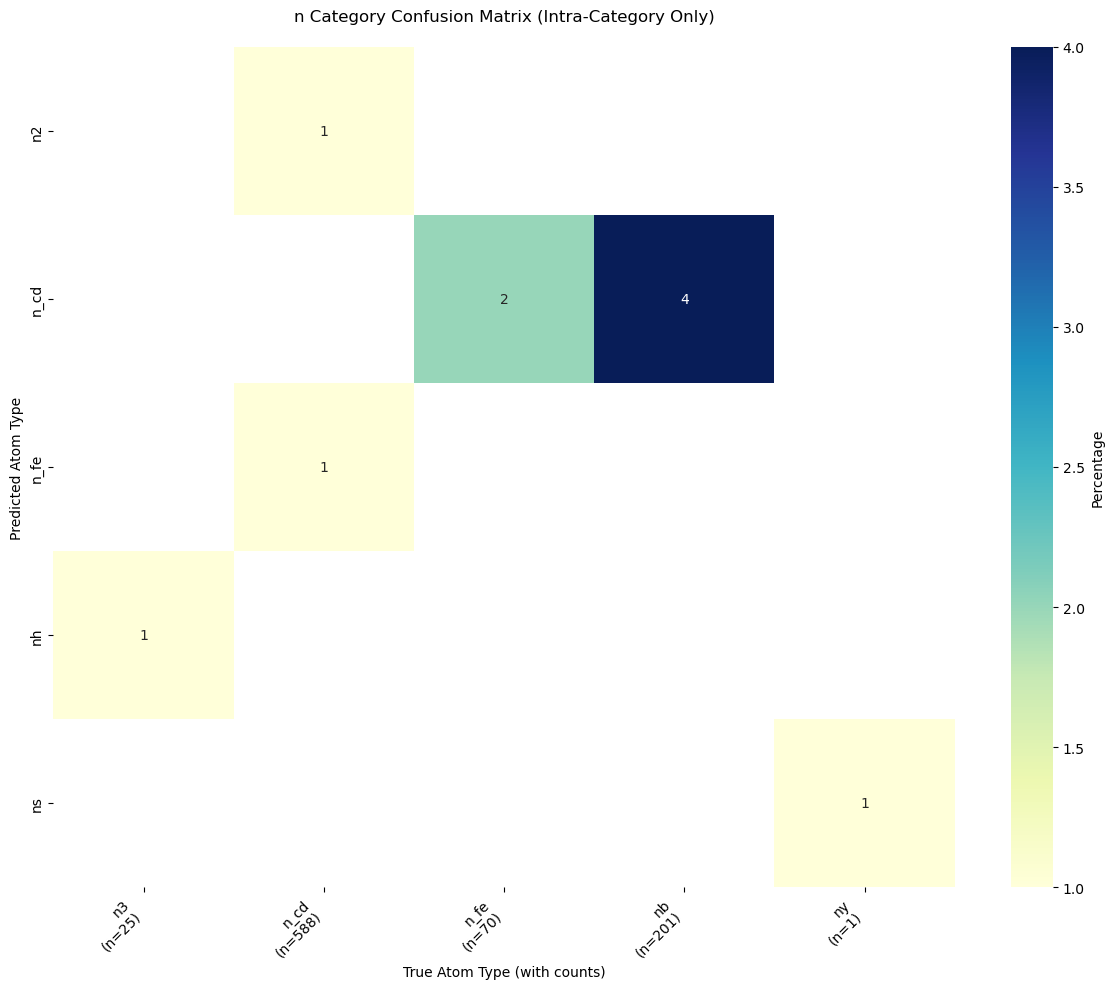

In [23]:
plot_category_confusion_matrices(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN)